# Taller 3.1 — Algoritmos de Rasterización Básica

## Objetivo
Implementar los algoritmos clásicos de rasterización **píxel a píxel** sin librerías de alto nivel:
- Algoritmo de Bresenham para líneas
- Algoritmo del Punto Medio para círculos
- Relleno de triángulos por scanline

## 1. Instalación Automática de Dependencias

In [1]:
import subprocess
import sys

libraries = ['pillow', 'matplotlib', 'imageio']

for lib in libraries:
    import_name = 'PIL' if lib == 'pillow' else lib
    try:
        __import__(import_name)
        print(f'✓ {lib} ya está instalado')
    except ImportError:
        print(f'Installing {lib}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', lib, '-q'])
        print(f'✓ {lib} instalado correctamente')

print('\n✅ Todas las dependencias están listas!')

✓ pillow ya está instalado


✓ matplotlib ya está instalado
Installing imageio...


✓ imageio instalado correctamente

✅ Todas las dependencias están listas!


You should consider upgrading via the '/Users/gabotachak/github.com/gabotachak/visualcomputing2026-i/.venv/bin/python3 -m pip install --upgrade pip' command.


## 2. Importar Librerías

In [2]:
from PIL import Image
import matplotlib.pyplot as plt
import imageio
import os
import numpy as np

print('✓ Librerías importadas correctamente')

✓ Librerías importadas correctamente


## 3. Constantes Globales

In [3]:
WIDTH, HEIGHT = 200, 200
BG_COLOR = (20, 20, 30)       # fondo oscuro
LINE_COLOR = (0, 220, 180)    # cian
CIRCLE_COLOR = (255, 180, 0)  # naranja
FILL_COLOR = (200, 60, 200)   # violeta

MEDIA_DIR = '../media'
os.makedirs(MEDIA_DIR, exist_ok=True)
print(f'Canvas {WIDTH}×{HEIGHT} — carpeta media: {MEDIA_DIR}')

Canvas 200×200 — carpeta media: ../media


## 4. Setup del Canvas

Creamos una imagen RGB con Pillow y accedemos a su mapa de píxeles.

In [4]:
def new_canvas():
    """Crea un canvas limpio con fondo BG_COLOR."""
    img = Image.new('RGB', (WIDTH, HEIGHT), BG_COLOR)
    return img, img.load()

img, px = new_canvas()
print(f'Imagen creada: modo={img.mode}, tamaño={img.size}')

Imagen creada: modo=RGB, tamaño=(200, 200)


## 5. Algoritmo de Bresenham (Línea)

Genera los píxeles de una línea de `(x0,y0)` a `(x1,y1)` usando aritmética entera pura.
Maneja todos los octantes mediante el signo incremental de cada eje.

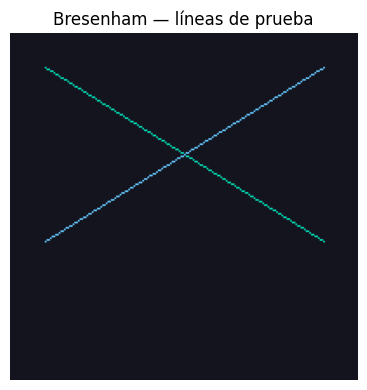

In [5]:
def bresenham(x0, y0, x1, y1):
    """Devuelve lista de píxeles (x,y) de la línea usando el algoritmo de Bresenham."""
    pixels = []
    dx = abs(x1 - x0)
    dy = abs(y1 - y0)
    sx = 1 if x0 < x1 else -1
    sy = 1 if y0 < y1 else -1
    err = dx - dy

    while True:
        pixels.append((x0, y0))
        if x0 == x1 and y0 == y1:
            break
        e2 = 2 * err
        if e2 > -dy:
            err -= dy
            x0 += sx
        if e2 < dx:
            err += dx
            y0 += sy
    return pixels


def draw_line(px, x0, y0, x1, y1, color):
    for (x, y) in bresenham(x0, y0, x1, y1):
        if 0 <= x < WIDTH and 0 <= y < HEIGHT:
            px[x, y] = color


# Test: línea de (20,20) → (180,120)
img, px = new_canvas()
draw_line(px, 20, 20, 180, 120, LINE_COLOR)
draw_line(px, 180, 20, 20, 120, (100, 200, 255))   # línea extra con pendiente negativa

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis('off')
plt.title('Bresenham — líneas de prueba')
plt.tight_layout()
plt.show()

## 6. Algoritmo del Punto Medio (Círculo)

Genera los 8 octantes de un círculo usando la condición de decisión del punto medio.

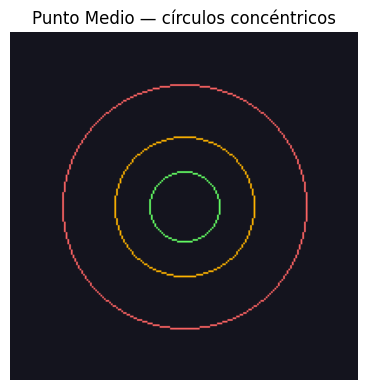

In [6]:
def midpoint_circle(x0, y0, radius):
    """Devuelve lista de píxeles del borde del círculo (8-way symmetry)."""
    pixels = []
    x = radius
    y = 0
    p = 1 - radius   # parámetro de decisión inicial

    def add_octants(cx, cy, x, y):
        for px_pt in [
            (cx+x, cy+y), (cx-x, cy+y),
            (cx+x, cy-y), (cx-x, cy-y),
            (cx+y, cy+x), (cx-y, cy+x),
            (cx+y, cy-x), (cx-y, cy-x),
        ]:
            pixels.append(px_pt)

    add_octants(x0, y0, x, y)
    while x > y:
        y += 1
        if p <= 0:
            p += 2*y + 1
        else:
            x -= 1
            p += 2*y - 2*x + 1
        add_octants(x0, y0, x, y)
    return pixels


def draw_circle(px, x0, y0, radius, color):
    for (x, y) in midpoint_circle(x0, y0, radius):
        if 0 <= x < WIDTH and 0 <= y < HEIGHT:
            px[x, y] = color


# Test: centro (100,100), radio 40
img, px = new_canvas()
draw_circle(px, 100, 100, 40, CIRCLE_COLOR)
draw_circle(px, 100, 100, 70, (255, 100, 100))  # círculo extra
draw_circle(px, 100, 100, 20, (100, 255, 100))  # círculo interior

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis('off')
plt.title('Punto Medio — círculos concéntricos')
plt.tight_layout()
plt.show()

## 7. Relleno de Triángulo (Scanline)

El algoritmo:
1. Ordena los tres vértices por coordenada Y.
2. Divide el triángulo en mitad superior e inferior.
3. Para cada scanline, interpola los bordes izquierdo y derecho y rellena los píxeles entre ellos.

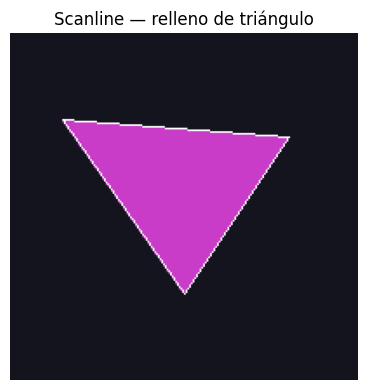

In [7]:
def fill_triangle(px, p1, p2, p3, color):
    """Rellena un triángulo usando scanline con interpolación de bordes."""
    # Ordenar vértices por Y
    verts = sorted([p1, p2, p3], key=lambda v: v[1])
    (x0, y0), (x1, y1), (x2, y2) = verts

    def interpolate_x(ya, yb, xa, xb, y):
        """Interpola X dado Y entre dos extremos."""
        if yb == ya:
            return xa
        return xa + (xb - xa) * (y - ya) / (yb - ya)

    def scanline_segment(y_start, y_end, xa_top, xa_bot, xb_top, xb_bot, ya, yb):
        for y in range(max(0, int(y_start)), min(HEIGHT, int(y_end) + 1)):
            xl = int(interpolate_x(ya, yb, xa_top, xa_bot, y))
            xr = int(interpolate_x(ya, yb, xb_top, xb_bot, y))
            if xl > xr:
                xl, xr = xr, xl
            for x in range(max(0, xl), min(WIDTH, xr + 1)):
                px[x, y] = color

    # Mitad inferior: y0 → y1
    if y1 != y0:
        for y in range(max(0, int(y0)), min(HEIGHT, int(y1) + 1)):
            xl = int(interpolate_x(y0, y1, x0, x1, y))
            xr = int(interpolate_x(y0, y2, x0, x2, y))
            if xl > xr:
                xl, xr = xr, xl
            for x in range(max(0, xl), min(WIDTH, xr + 1)):
                px[x, y] = color

    # Mitad superior: y1 → y2
    if y2 != y1:
        for y in range(max(0, int(y1)), min(HEIGHT, int(y2) + 1)):
            xl = int(interpolate_x(y1, y2, x1, x2, y))
            xr = int(interpolate_x(y0, y2, x0, x2, y))
            if xl > xr:
                xl, xr = xr, xl
            for x in range(max(0, xl), min(WIDTH, xr + 1)):
                px[x, y] = color


# Test con los puntos del enunciado
img, px = new_canvas()
fill_triangle(px, (30, 50), (100, 150), (160, 60), FILL_COLOR)
# Dibujar los bordes encima para contexto
draw_line(px, 30, 50, 100, 150, (255, 255, 255))
draw_line(px, 100, 150, 160, 60, (255, 255, 255))
draw_line(px, 160, 60, 30, 50, (255, 255, 255))

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis('off')
plt.title('Scanline — relleno de triángulo')
plt.tight_layout()
plt.show()

## 8. Visualización Final — Escena Completa

Combinamos los tres algoritmos en un solo canvas.

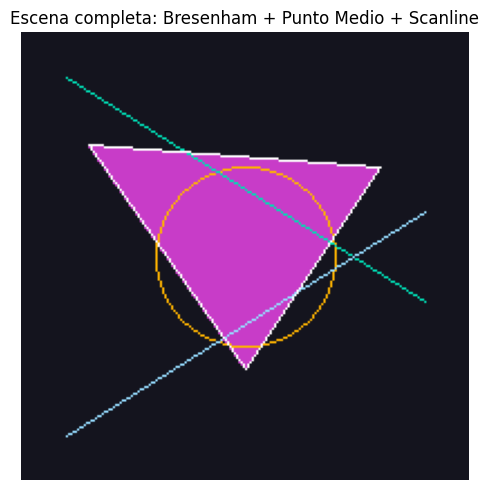

✓ Guardada: ../media/escena_completa.png


In [8]:
img_final, px_f = new_canvas()

# Triángulo relleno
fill_triangle(px_f, (30, 50), (100, 150), (160, 60), FILL_COLOR)

# Círculo
draw_circle(px_f, 100, 100, 40, CIRCLE_COLOR)

# Líneas diagonales
draw_line(px_f, 20, 20, 180, 120, LINE_COLOR)
draw_line(px_f, 20, 180, 180, 80, (150, 220, 255))

# Bordes del triángulo
draw_line(px_f, 30, 50, 100, 150, (255, 255, 255))
draw_line(px_f, 100, 150, 160, 60, (255, 255, 255))
draw_line(px_f, 160, 60, 30, 50, (255, 255, 255))

plt.figure(figsize=(5, 5))
plt.imshow(img_final)
plt.axis('off')
plt.title('Escena completa: Bresenham + Punto Medio + Scanline')
plt.tight_layout()
plt.show()

# Guardar imagen
out_scene = os.path.join(MEDIA_DIR, 'escena_completa.png')
img_final.save(out_scene)
print(f'✓ Guardada: {out_scene}')

## 9. GIF Animado — Construcción de la Escena

Generamos un GIF que muestra la construcción progresiva de los elementos.

In [9]:
print('🎬 Generando GIF animado...')

frames = []
gif_path = os.path.join(MEDIA_DIR, 'rasterizacion_construccion.gif')

# ---- Fase 1: Bresenham (líneas) ----
# Construir la línea punto a punto
line_pixels = bresenham(20, 20, 180, 120)
line_pixels2 = bresenham(20, 180, 180, 80)

img_anim, px_a = new_canvas()
step = max(1, len(line_pixels) // 20)
for i in range(0, len(line_pixels), step):
    for (x, y) in line_pixels[:i]:
        if 0 <= x < WIDTH and 0 <= y < HEIGHT:
            px_a[x, y] = LINE_COLOR
    for (x, y) in line_pixels2[:i]:
        if 0 <= x < WIDTH and 0 <= y < HEIGHT:
            px_a[x, y] = (150, 220, 255)
    frame = np.array(img_anim.copy())
    frames.append(frame)

# ---- Fase 2: Círculo ----
img_anim2, px_a2 = Image.new('RGB', (WIDTH, HEIGHT), BG_COLOR), None
img_anim2.paste(img_anim)   # partir del estado anterior
px_a2 = img_anim2.load()

circle_pixels = midpoint_circle(100, 100, 40)
step_c = max(1, len(circle_pixels) // 20)
for i in range(0, len(circle_pixels), step_c):
    for (x, y) in circle_pixels[:i]:
        if 0 <= x < WIDTH and 0 <= y < HEIGHT:
            px_a2[x, y] = CIRCLE_COLOR
    frames.append(np.array(img_anim2.copy()))

# ---- Fase 3: Triángulo scanline ----
img_anim3 = img_anim2.copy()
px_a3 = img_anim3.load()

verts = sorted([(30,50),(100,150),(160,60)], key=lambda v: v[1])
(x0,y0),(x1,y1),(x2,y2) = verts

def interp_x(ya, yb, xa, xb, y):
    if yb == ya: return xa
    return xa + (xb - xa) * (y - ya) / (yb - ya)

scanlines_to_draw = []
for y in range(max(0, int(y0)), min(HEIGHT, int(y2) + 1)):
    if y <= y1:
        xl = int(interp_x(y0, y1, x0, x1, y))
        xr = int(interp_x(y0, y2, x0, x2, y))
    else:
        xl = int(interp_x(y1, y2, x1, x2, y))
        xr = int(interp_x(y0, y2, x0, x2, y))
    if xl > xr: xl, xr = xr, xl
    scanlines_to_draw.append((y, xl, xr))

step_t = max(1, len(scanlines_to_draw) // 20)
for i in range(0, len(scanlines_to_draw), step_t):
    for (y, xl, xr) in scanlines_to_draw[:i]:
        for x in range(max(0, xl), min(WIDTH, xr+1)):
            px_a3[x, y] = FILL_COLOR
    frames.append(np.array(img_anim3.copy()))

# Frame final con bordes
draw_line(px_a3, 30, 50, 100, 150, (255,255,255))
draw_line(px_a3, 100, 150, 160, 60, (255,255,255))
draw_line(px_a3, 160, 60, 30, 50, (255,255,255))
for _ in range(10):
    frames.append(np.array(img_anim3.copy()))

imageio.mimsave(gif_path, frames, duration=0.08)
print(f'✓ GIF guardado: {gif_path} ({len(frames)} frames)')

🎬 Generando GIF animado...


✓ GIF guardado: ../media/rasterizacion_construccion.gif (72 frames)


## 10. Comparación de Algoritmos — Visualización Grid

Mostramos los tres algoritmos lado a lado para una comparación clara.

✓ Comparación guardada: ../media/comparacion_algoritmos.png


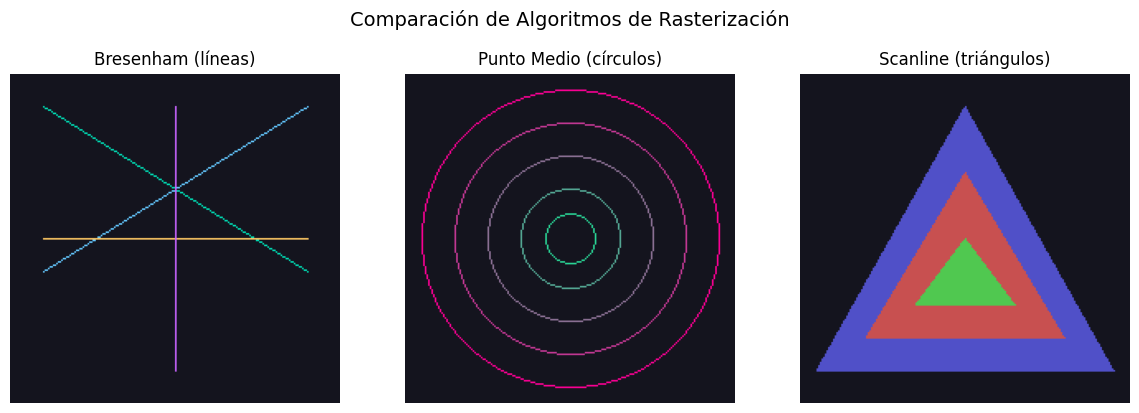

In [10]:
# Canvas 1: Solo Bresenham
img_b, px_b = new_canvas()
draw_line(px_b, 20, 20, 180, 120, LINE_COLOR)
draw_line(px_b, 180, 20, 20, 120, (100, 200, 255))
draw_line(px_b, 20, 100, 180, 100, (255, 200, 100))
draw_line(px_b, 100, 20, 100, 180, (200, 100, 255))

# Canvas 2: Solo círculos
img_c, px_c = new_canvas()
for r in [15, 30, 50, 70, 90]:
    hue = int(r / 90 * 255)
    draw_circle(px_c, 100, 100, r, (hue, 255 - hue, 150))

# Canvas 3: Triángulos apilados
img_t, px_t = new_canvas()
fill_triangle(px_t, (10, 180), (100, 20), (190, 180), (80, 80, 200))
fill_triangle(px_t, (40, 160), (100, 60), (160, 160), (200, 80, 80))
fill_triangle(px_t, (70, 140), (100, 100), (130, 140), (80, 200, 80))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_b); axes[0].axis('off'); axes[0].set_title('Bresenham (líneas)')
axes[1].imshow(img_c); axes[1].axis('off'); axes[1].set_title('Punto Medio (círculos)')
axes[2].imshow(img_t); axes[2].axis('off'); axes[2].set_title('Scanline (triángulos)')
plt.suptitle('Comparación de Algoritmos de Rasterización', fontsize=14, y=1.02)
plt.tight_layout()

comparison_path = os.path.join(MEDIA_DIR, 'comparacion_algoritmos.png')
plt.savefig(comparison_path, dpi=120, bbox_inches='tight')
print(f'✓ Comparación guardada: {comparison_path}')
plt.show()

## Resumen

| Algoritmo | Complejidad | Observaciones |
|---|---|---|
| Bresenham (línea) | O(max(Δx, Δy)) | Solo aritmética entera, muy eficiente |
| Punto medio (círculo) | O(r) | Aprovecha simetría de 8 octantes |
| Scanline (triángulo) | O(area) | Interpolación de bordes por cada scanline |